In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("river-plastics.csv")
df.columns


Index(['Country or administrative area', 'Area', 'Coast length', 'Rainfall',
       'MPW', 'ME', 'Ratio ME/MPW'],
      dtype='object')

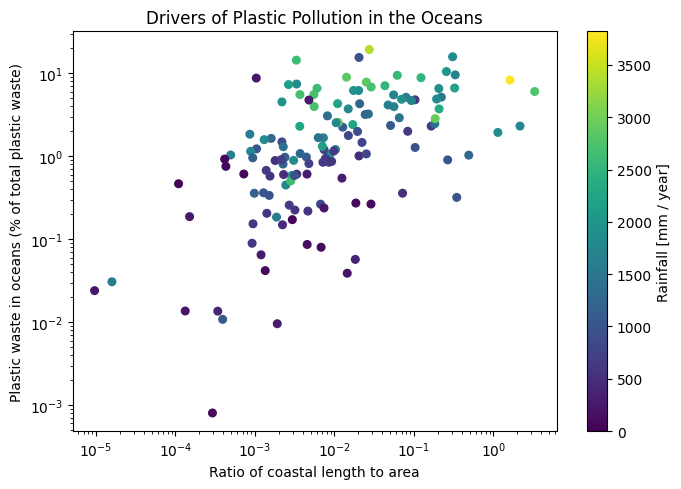

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("river-plastics.csv")

df = df[["Area", "Coast length", "Rainfall", "MPW", "ME"]].dropna()
df = df[(df["Area"] > 0) & (df["Coast length"] > 0) & (df["MPW"] > 0) & (df["ME"] > 0)]

x = df["Coast length"] / df["Area"]  
y = (df["ME"] / df["MPW"]) * 100     
c = df["Rainfall"]                  

fig, ax = plt.subplots(figsize=(7, 5))

sc = ax.scatter(x, y, c=c, cmap="viridis", s=30, vmin=0, vmax=c.max())  

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_title("Drivers of Plastic Pollution in the Oceans")
ax.set_xlabel("Ratio of coastal length to area")
ax.set_ylabel("Plastic waste in oceans (% of total plastic waste)")

cb = fig.colorbar(sc, ax=ax)
cb.set_label("Rainfall [mm / year]")

plt.tight_layout()
plt.show()


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

sleep = pd.read_csv("sleep.csv")
print(sleep.columns)


Index(['Age group', 'Min age', 'Max age', 'Not recommended lower',
       'Approriate lower', 'Recommended lower', 'Recommended upper',
       'Appropriate upper', 'Not recommended upper'],
      dtype='object')


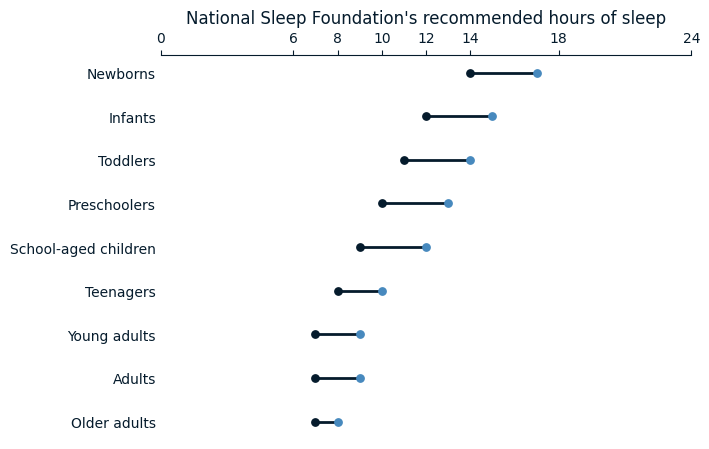

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

sleep = pd.read_csv("sleep.csv")

DARK = "#051B2C"
BLUE = "#4789BE"

Age_Column = "Age group"
Rec_Min = "Recommended lower"
Rec_Max = "Recommended upper"

order = [
    "Newborns", "Infants", "Toddlers", "Preschoolers",
    "School-aged children", "Teenagers", "Young adults", "Adults", "Older adults"
]

df = sleep[[Age_Column, Rec_Min, Rec_Max]].dropna()
df = df[df[Age_Column].isin(order)]
df[Age_Column] = pd.Categorical(df[Age_Column], categories=order, ordered=True)
df = df.sort_values(Age_Column)

fig, ax = plt.subplots(figsize=(7.2, 4.6))

y = range(len(df))
for yi, lo, hi in zip(y, df[Rec_Min], df[Rec_Max]):
    ax.plot([lo, hi], [yi, yi], color=DARK, linewidth=2)  
    ax.scatter(lo, yi, s=28, color=DARK, zorder=3)
    ax.scatter(hi, yi, s=28, color=BLUE, zorder=3)

ax.set_yticks(list(y))
ax.set_yticklabels(df[Age_Column])

ax.set_xlim(0, 24)
ax.set_xticks([0, 6, 8, 10, 12, 14, 18, 24])
ax.xaxis.tick_top()
ax.tick_params(axis="x", top=True, labeltop=True, bottom=False, labelbottom=False, colors=DARK)
ax.tick_params(axis="y", length=0, colors=DARK)

ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_color(DARK)

ax.spines["top"].set_visible(True)
ax.spines["top"].set_bounds(0, 24)
ax.set_title("National Sleep Foundation's recommended hours of sleep", color=DARK)
ax.invert_yaxis()

plt.tight_layout()
plt.show()
